In this notebook, yields are predicted for the full ArBr search space using a random forest regression model.

NOTE: This notebook was run with a different python environment (arbr_modeling --> see modeling_environment.yml file in this folder).

In [1]:
import colorsys
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

from rdkit import Chem
from rdkit.Chem import Draw, rdFingerprintGenerator, Descriptors

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

# Doyle colors
doyle_colors = ["#CE4C6F", "#1561C2", "#188F9D","#C4ADA2","#515798", "#CB7D85", "#A9A9A9"]
# extension of palette with lighter and darker versions
def adjust_lightness(color, factor=1.2):
    """
    Function to make colors lighter (factor > 1) or darker (factor < 1).
    """
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return mcolors.to_hex((r, g, b))

lighter = [adjust_lightness(c, 1.2) for c in doyle_colors]
darker  = [adjust_lightness(c, 0.7) for c in doyle_colors]
all_colors = doyle_colors + darker + lighter

# Save the categorical colormap
cat_cmap = ListedColormap(all_colors, name="Doyle_cat")
plt.colormaps.register(cat_cmap)

# Define and save a continuous colormap
colors = [doyle_colors[1],"#FFFFFFD1",doyle_colors[0]]
cont_cmap = LinearSegmentedColormap.from_list("Doyle_cont", colors)
plt.colormaps.register(cont_cmap)

# General plt parameters
plt.rcParams.update({
    "axes.titlesize": 20,        # Subplot title
    "axes.labelsize": 16,        # X and Y labels
    "figure.titlesize": 24,      # Suptitle
    "xtick.labelsize": 14,       # X tick labels
    "ytick.labelsize": 14,       # Y tick labels
    "legend.fontsize": 14,       # Legend text
    "legend.title_fontsize": 14  # Legend titles
})

### Read in the experimental data

In [2]:
# read in the NMR yields from the modeling part of the prior study

nmr_yields = pd.read_csv("arbr_nmr_yields.csv",index_col=0,header=0)
nmr_yields.head()

,yield,type,name,ortho,meta,para,subs,TBABr
smi,,,,,,,,
CC(=O)c1ccc(cc1)Br,90,lit,4-Ac,0,0,1,para,0
Brc1ccc(cc1)C(=O)c1ccccc1,90,lit,4-COPh,0,0,1,para,0
N#Cc1ccccc1Br,82,lit,2-CN,1,0,0,ortho,0
N#Cc1ccc(cc1)Br,80,lit,4-CN,0,0,1,para,0
BrC1=CC=C(C=O)C=C1,52,lit,4-CHO,0,0,1,para,0


In [3]:
nmr_yields = nmr_yields.drop(labels=["name","type","ortho","meta","para","subs"],axis=1)  # drop unnecessary columns
len(nmr_yields)

52

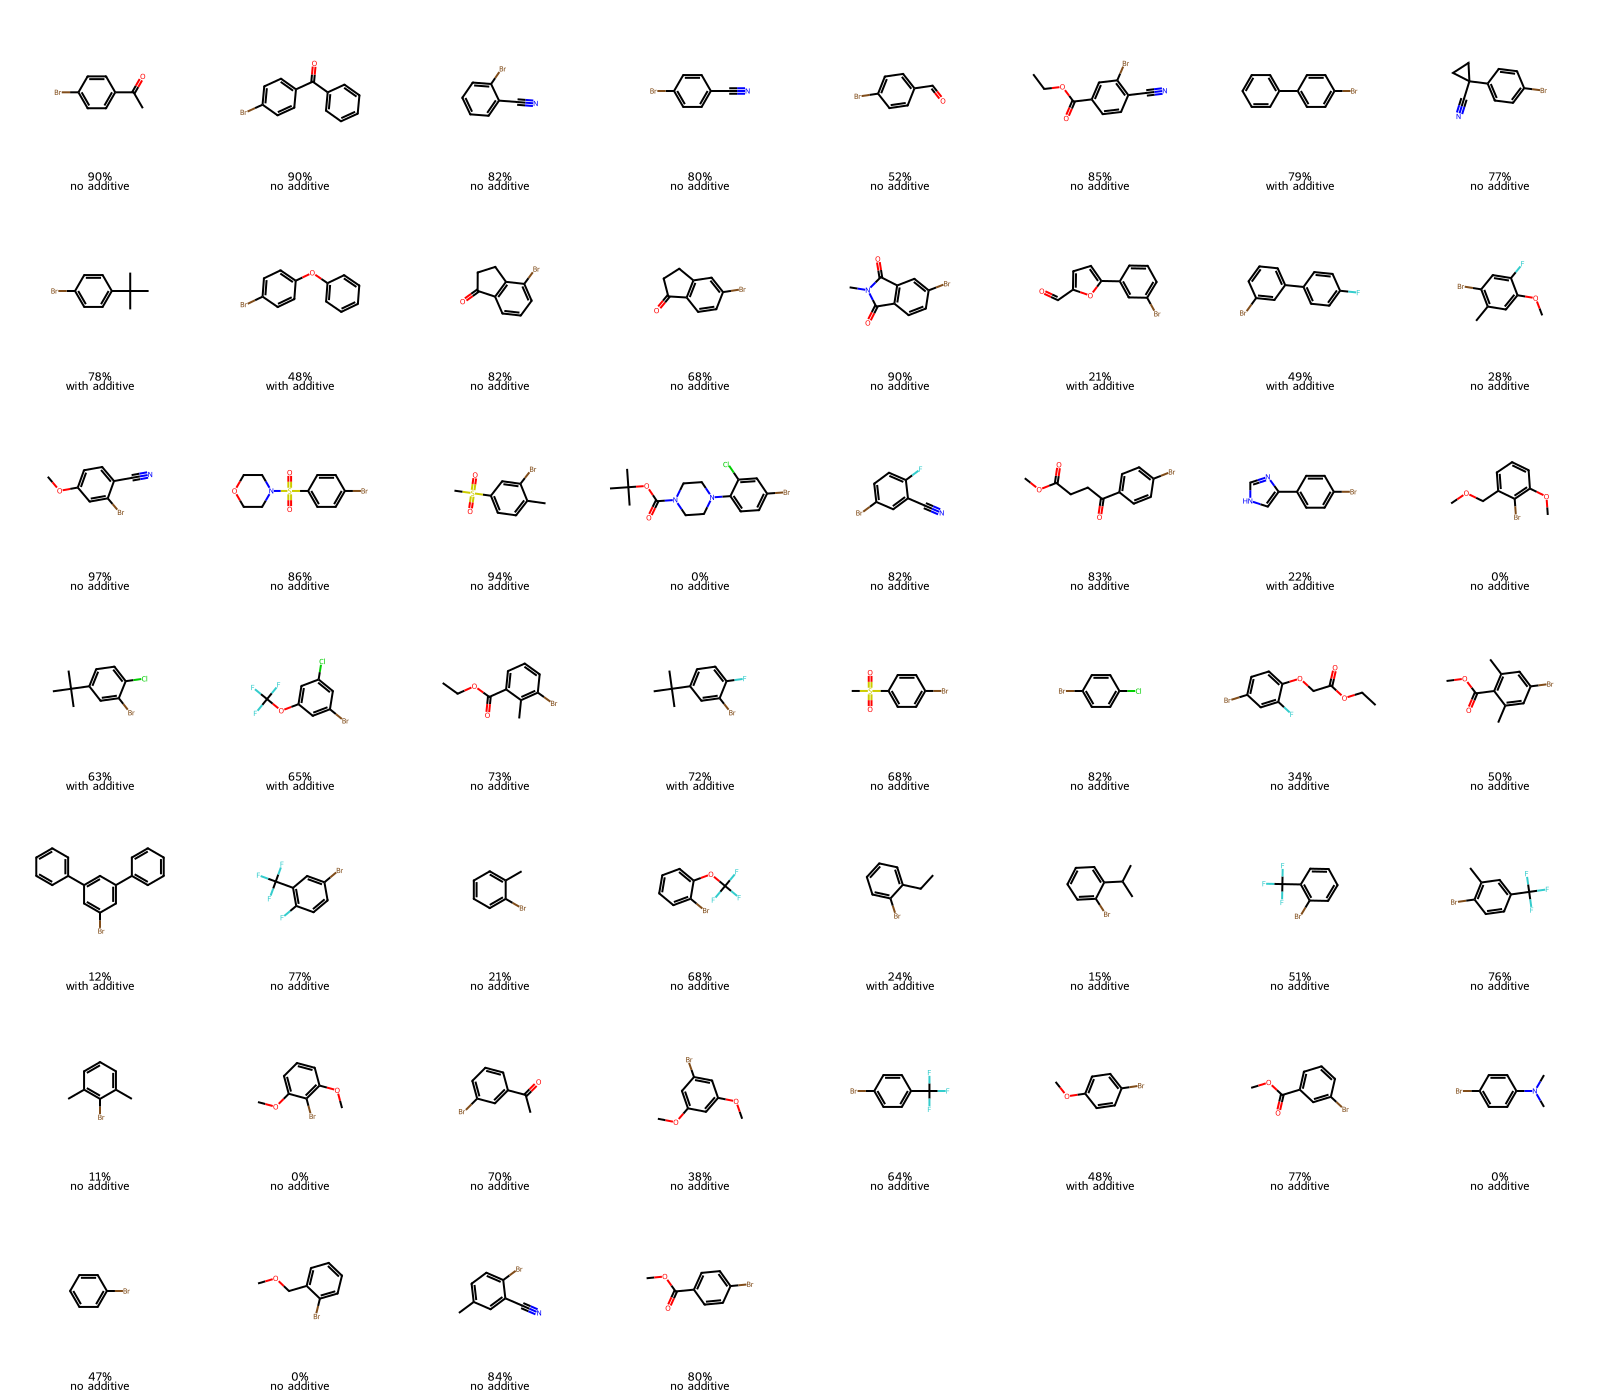

In [4]:
# draw the molecules in the dataset with their yields
Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in nmr_yields.index], 
                     legends = [f"{str(nmr_yields.loc[idx,'yield'])+'%'}\n{'no additive' if nmr_yields.loc[idx,'TBABr'] == 0 else 'with additive'}" for idx in nmr_yields.index], molsPerRow=8, maxMols=1000)

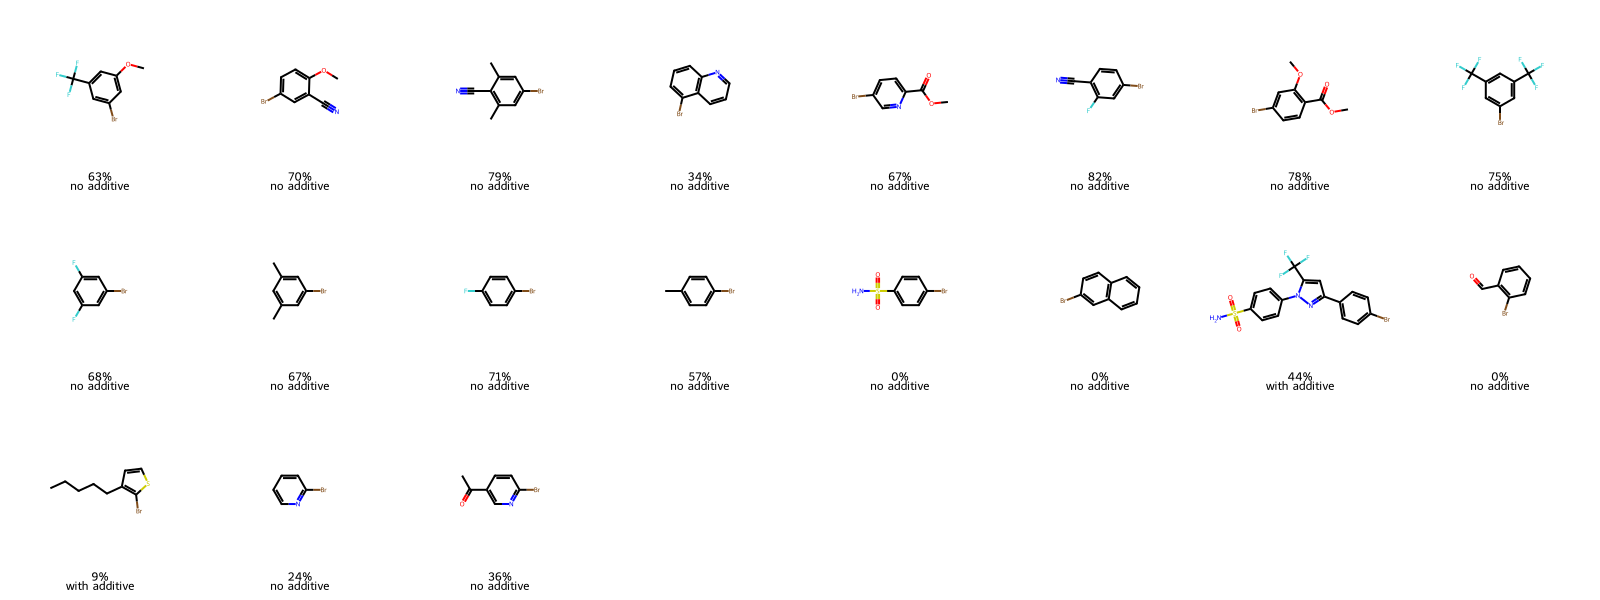

In [5]:
# data for other compounds from that study (isolated yields in this case)
more_data = {
    "c1(Br)cc(C(F)(F)F)cc(OC)c1": [63,0],
    "c1(Br)ccc(OC)c(C#N)c1": [70,0],
    "c1(Br)cc(C)c(C#N)c(C)c1": [79,0],
    "BrC1=CC=CC2=C1C=CC=N2": [34,0],
    "n1cc(Br)ccc1C(=O)OC": [67,0],
    "c1(Br)cc(F)c(C#N)cc1": [82,0],
    "c1(Br)cc(OC)c(C(=O)OC)cc1": [78,0],
    "c1(Br)cc(C(F)(F)F)cc(C(F)(F)F)c1": [75,0],
    "c1(Br)cc(F)cc(F)c1": [68,0],
    "c1(Br)cc(C)cc(C)c1": [67,0],
    "c1(Br)ccc(F)cc1": [71,0],
    "c1(Br)ccc(C)cc1": [57,0],
    "c1(Br)ccc(S(=O)(=O)N)cc1": [0,0],
    "C1=C(Br)C=CC2=C1C=CC=C2": [0,0],
    "NS(=O)(=O)c1ccc(n2c(C(F)(F)F)cc(c3ccc(Br)cc3)n2)cc1": [44,1],
    "Brc1c(C(=O))cccc1": [0,0],
    "Brc1sccc1CCCCC": [9,1],
    "Brc1ncccc1": [24,0],
    "Brc1ncc(C(=O)C)cc1": [36,0]}

Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in more_data.keys()], 
                     legends = [f"{str(x[0])+'%'}\n{'no additive' if x[1] == 0 else 'with additive'}" for x in more_data.values()], molsPerRow=8)

In [6]:
# combine the experimental data
train = nmr_yields.copy()
for smiles, data in more_data.items():
    train.loc[smiles,"yield"] = data[0]
    train.loc[smiles,"TBABr"] = data[1]
# canonicalize the smiles
train.index = [Chem.MolToSmiles(Chem.MolFromSmiles(x)) for x in train.index]
# drop potential duplicates
print("Number of removed duplicates:",len(train[train.index.duplicated()]))
train = train.loc[~train.index.duplicated()]
train["SMILES"] = train.index
train = train.reset_index(drop=True)

print("Number of compounds with yields:", len(train))
train.head()

Number of removed duplicates: 0
Number of compounds with yields: 71


,yield,TBABr,SMILES
0,90.0,0.0,CC(=O)c1ccc(Br)cc1
1,90.0,0.0,O=C(c1ccccc1)c1ccc(Br)cc1
2,82.0,0.0,N#Cc1ccccc1Br
3,80.0,0.0,N#Cc1ccc(Br)cc1
4,52.0,0.0,O=Cc1ccc(Br)cc1


In [7]:
def hist_plot(data, column,label,bins = 10, bin_edges = (0,100), print_labels=True, figsize=(5,4),dpi = 200):
    """Functon for plotting histograms."""
    plt.figure(figsize=figsize, dpi = dpi)
    bin_val = bins
    if bin_edges is not None:
        bin_val = np.linspace(bin_edges[0],bin_edges[1],bins+1)
    plt.hist(data[column], color=all_colors[6], bins=bin_val, edgecolor="k")
    if print_labels:
        plt.xlabel(label)
        plt.ylabel("Count")
    else:
        plt.xticks([])
        plt.yticks([])
    plt.tight_layout()
    plt.show()

Yield distribution full training dataset:
Average yield: 54.3 %
Fraction with < 10% yield: 13 %
Fraction with ≥ 90% yield: 7 %


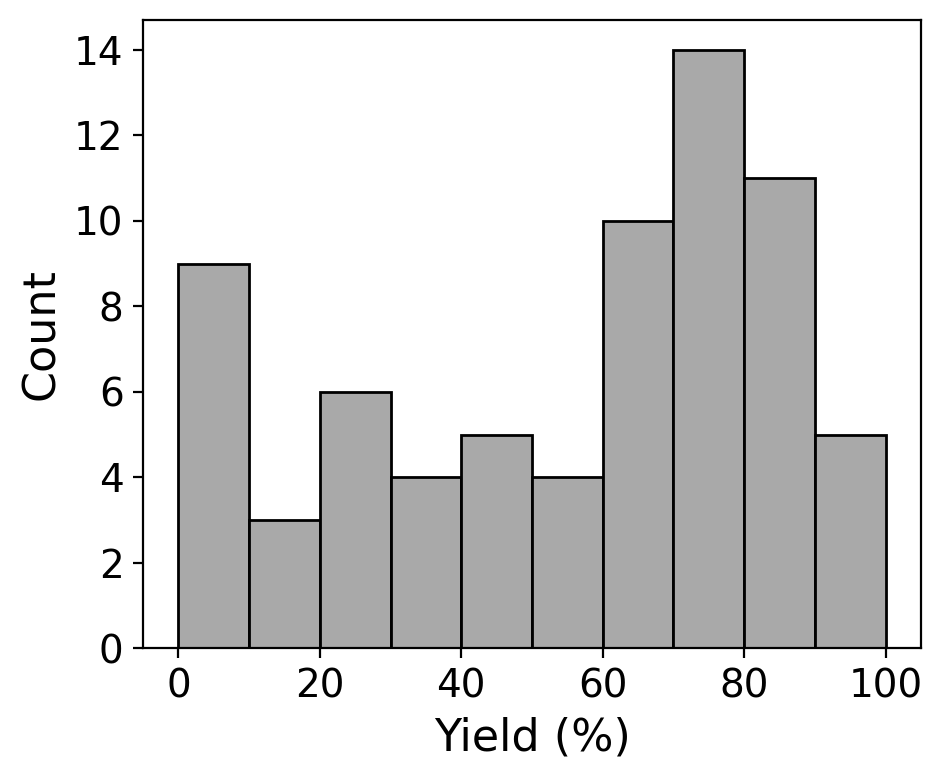

In [8]:
print("Yield distribution full training dataset:")
print("Average yield:", round(train["yield"].mean(),1),"%")
print("Fraction with < 10% yield:", round(len(train[train["yield"] < 10])/len(train)*100),"%")
print("Fraction with ≥ 90% yield:", round(len(train[train["yield"] >= 90])/len(train)*100),"%")

hist_plot(train,"yield",label="Yield (%)")

In [9]:
# load the entire search space
space_smiles = pd.read_csv("arbr_smiles.csv",names=["SMILES"])["SMILES"].to_list()
space_smiles = [Chem.MolToSmiles(Chem.MolFromSmiles(x)) for x in space_smiles]
print("Number of loaded search space compounds:",len(space_smiles), "\n")

print("Pruning compounds with experimental data...")
candidates = [smiles for smiles in space_smiles]
i = 0
not_found = []
for smiles in train["SMILES"].unique():
    try:
        candidates.remove(smiles)
    except:
        not_found.append(smiles)
        i += 1
print(i, "experimental compounds are not in the search space of the original paper:")
print(not_found)
print("\nNumber of compounds for yield prediction:", len(candidates))

Number of loaded search space compounds: 2683 

Pruning compounds with experimental data...
12 experimental compounds are not in the search space of the original paper:
['N#CC1(c2ccc(Br)cc2)CC1', 'O=C1CCc2c(Br)cccc21', 'O=C1CCc2cc(Br)ccc21', 'CN1C(=O)c2ccc(Br)cc2C1=O', 'Brc1cccc2ncccc12', 'COC(=O)c1ccc(Br)cn1', 'NS(=O)(=O)c1ccc(Br)cc1', 'NS(=O)(=O)c1ccc(-n2nc(-c3ccc(Br)cc3)cc2C(F)(F)F)cc1', 'O=Cc1ccccc1Br', 'CCCCCc1ccsc1Br', 'Brc1ccccn1', 'CC(=O)c1ccc(Br)nc1']

Number of compounds for yield prediction: 2624


In [10]:
def featurize(smiles, radius=2, n_bits=2048):
    """Morgan fingerprints from a smiles list."""
    fps = []
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)

    for s in smiles:
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            raise ValueError(f"Invalid SMILES: {s}")
        fp = generator.GetFingerprint(mol)
        fps.append(fp)

    return np.array(fps)

In [11]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """Filter for highly correlated features."""

    def __init__(self, threshold=0.95):
        self.threshold = threshold


    def fit(self, X, y=None):

        corr = np.corrcoef(X, rowvar=False)
        upper = np.triu(np.ones(corr.shape), k=1).astype(bool)
        to_drop = []
        for i in range(corr.shape[0]):
            if any(abs(corr[i, upper[i]]) > self.threshold):
                to_drop.append(i)
        self.keep_idx = np.setdiff1d(np.arange(X.shape[1]), to_drop)

        return self


    def transform(self, X):
        return X[:, self.keep_idx]

In [12]:
def logit_transform(y):
    """Logit transformation for yields between 0 and 100."""

    y = np.clip(y, 1e-3, 100-1e-3)

    return np.log(y/(100-y))


def inverse_logit(z):
    """Inverse logit transformation to get back to natural yields."""
    return 100/(1+np.exp(-z))

In [13]:
#  define the features and labels
X = featurize(train["SMILES"])  # featurize the training compounds
y = train["yield"].values
X_cand = featurize(candidates)  # featurize the candidate compounds

In [14]:
# pipeline for feature preprocessing and RF model
pipeline = Pipeline([
    ("variance", VarianceThreshold()),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("model", RandomForestRegressor(random_state=0))])

# wrap the pipeline to automatically convert to logit-transformed yields in the modeling
model = TransformedTargetRegressor(regressor=pipeline,
                                   func = logit_transform,
                                   inverse_func = inverse_logit,
                                   check_inverse=False)

In [15]:
# parameters to test with the RF model
param_dist = {"regressor__model__n_estimators": [200, 400, 600, 800],
              "regressor__model__max_depth": [None, 5, 10, 15],
              "regressor__model__min_samples_split": [2, 3, 5, 10],
              "regressor__model__min_samples_leaf": [1, 2, 4, 6],
              "regressor__model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7],
              "regressor__model__bootstrap": [True]}

In [16]:
# bin the yields for stratification in the cross validation
kbd = KBinsDiscretizer(n_bins=5, encode="ordinal", strategy="quantile")
y_bins = kbd.fit_transform(y.reshape(-1,1)).astype(int).ravel()
print("Bin counts:", np.bincount(y_bins))

Bin counts: [14 14 13 14 16]


/opt/miniconda3/envs/arbr_modeling/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


In [17]:
# 10-times repeated 5x5 CV scheme to get the generalization error

outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats = 10, random_state=0)

r2_scores = []
mae_scores = []
rmse_scores = []

for train_idx, test_idx in tqdm(outer_cv.split(X, y_bins)):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

    search = RandomizedSearchCV(
        model,
        param_distributions=param_dist,
        n_iter=40,
        cv=inner_cv.split(X_train, y_bins[train_idx]),
        scoring="r2",
        n_jobs=-1,
        random_state=0
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    pred = best_model.predict(X_test)

    r2_scores.append(r2_score(y_test, pred))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, pred)))
    mae_scores.append(mean_absolute_error(y_test, pred))

50it [06:03,  7.27s/it]


In [18]:
print("Repeated Nested CV Results (10 times 5x5)\n")
print("R2 mean:", np.mean(r2_scores))
print("R2 std:", np.std(r2_scores))
print("RMSE mean:", np.mean(rmse_scores))
print("RMSE std:", np.std(rmse_scores))
print("MAE mean:", np.mean(mae_scores))
print("MAE std:", np.std(mae_scores))

Repeated Nested CV Results (10 times 5x5)

R2 mean: 0.014158856536248439
R2 std: 0.29505686808109544
RMSE mean: 28.894932823634036
RMSE std: 5.043638971333001
MAE mean: 22.46468227617686
MAE std: 4.197636596595634


In [19]:
# train the final model on the full data

search_final = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=80,
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=0).split(X,y_bins),
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    random_state=0
)

search_final.fit(X, y)

final_model = search_final.best_estimator_
print("Final model parameters:", search_final.best_params_)

Final model parameters: {'regressor__model__n_estimators': 600, 'regressor__model__min_samples_split': 2, 'regressor__model__min_samples_leaf': 1, 'regressor__model__max_features': 0.7, 'regressor__model__max_depth': 15, 'regressor__model__bootstrap': True}


Parity plot


<function matplotlib.pyplot.show(close=None, block=None)>

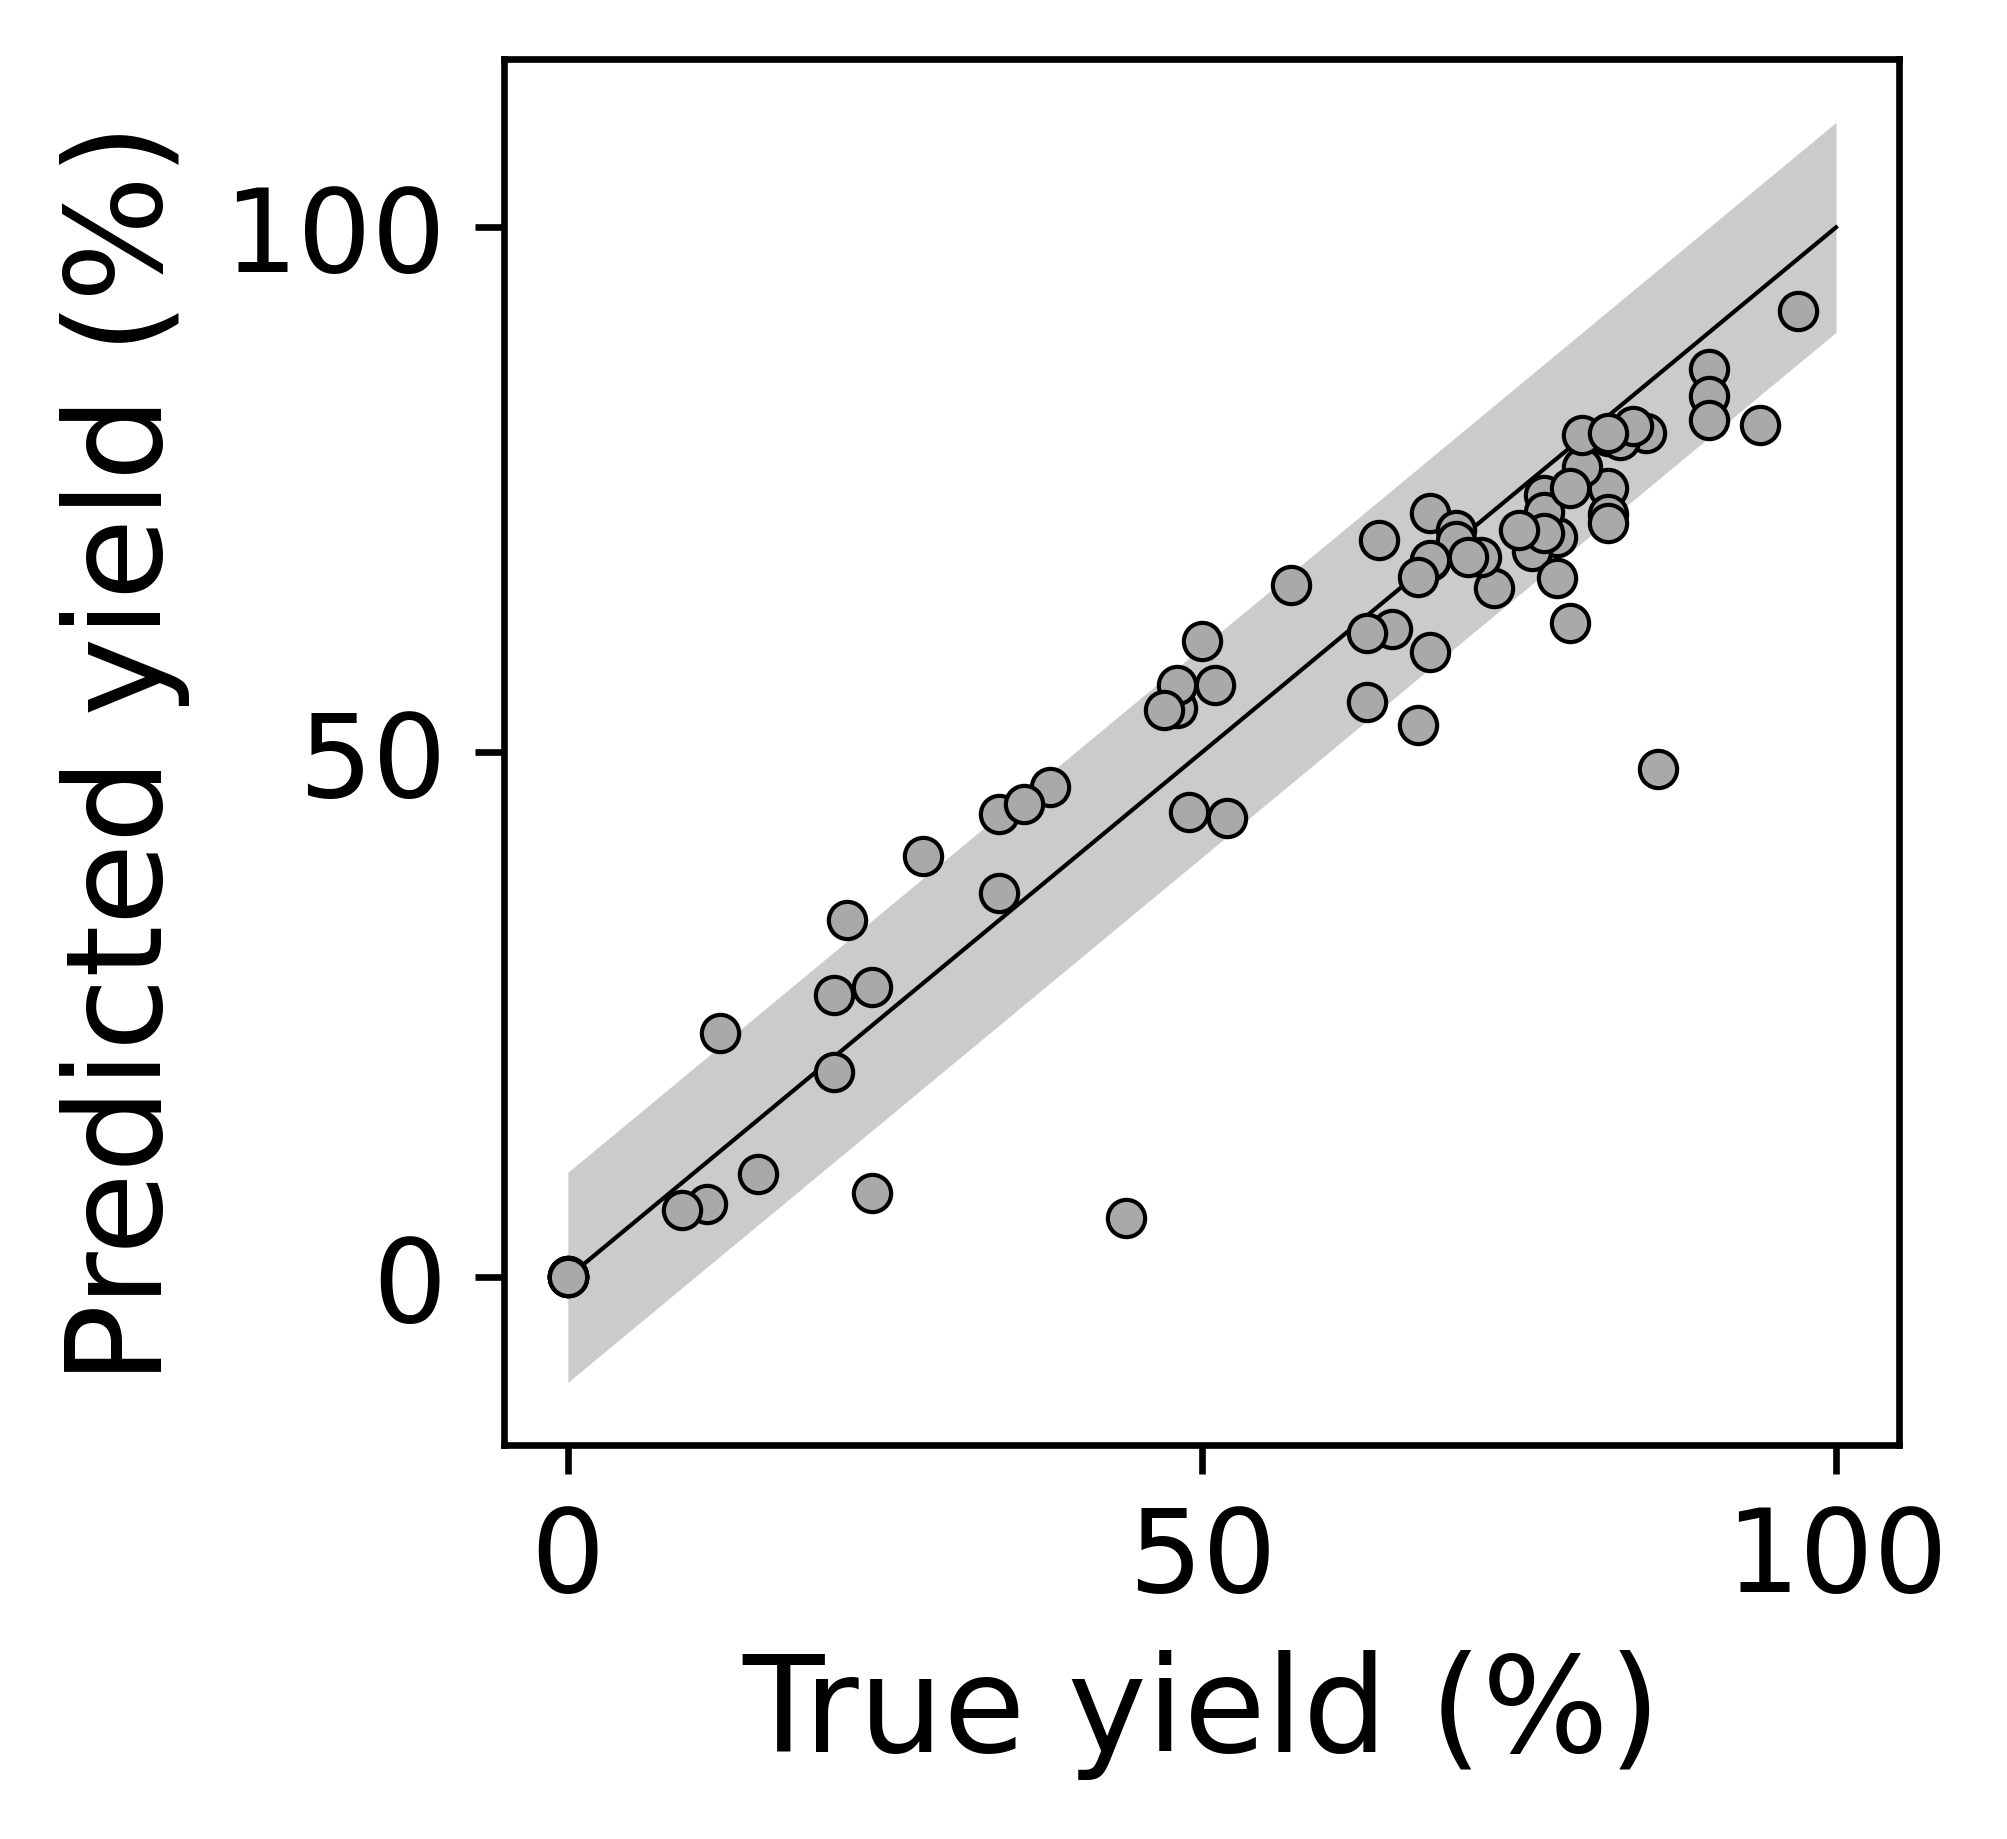

In [20]:
pred = final_model.predict(X)
print("Parity plot")
plt.figure(figsize=(3,3),dpi=600)
plt.scatter(y,pred, zorder = 1, s = 20, edgecolors="k", linewidths=0.5, c=all_colors[6])
x = np.linspace(0,100)
plt.fill_between(x,x-10,x+10, alpha = 1, color = all_colors[20], linewidths=0, zorder = 0)
plt.plot([0, 100], [0, 100], '-', color="black", zorder=0, linewidth=0.5)
plt.xlabel("True yield (%)")
plt.ylabel("Predicted yield (%)")
plt.show

Model outliers (defined here as abs(MAE) > 15%):


,yield,TBABr,SMILES,prediction,MAE
6,79.0,1.0,Brc1ccc(-c2ccccc2)cc1,62.362549,-16.637451
17,86.0,0.0,O=S(=O)(c1ccc(Br)cc1)N1CCOCC1,48.387325,-37.612675
36,24.0,1.0,CCc1ccccc1Br,8.014506,-15.985494
66,44.0,1.0,NS(=O)(=O)c1ccc(-n2nc(-c3ccc(Br)cc3)cc2C(F)(F)...,5.629196,-38.370804


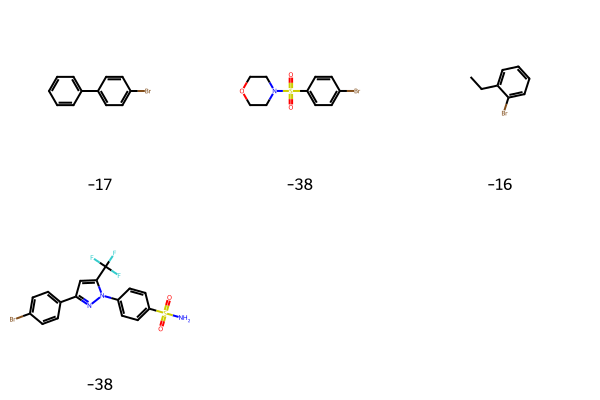

In [21]:
train["prediction"] = pred
train["MAE"] = train["prediction"]-train["yield"]
outliers = train[abs(train["MAE"]) > 15]["SMILES"].to_list()
print("Model outliers (defined here as abs(MAE) > 15%):")
display(train[abs(train["MAE"]) > 15])
Draw.MolsToGridImage([Chem.MolFromSmiles(smiles) for smiles in outliers], 
                     legends=[str(round(x)) for x in train[abs(train["MAE"]) > 15]["MAE"].to_list()])

Plot of the mean errors across the training data


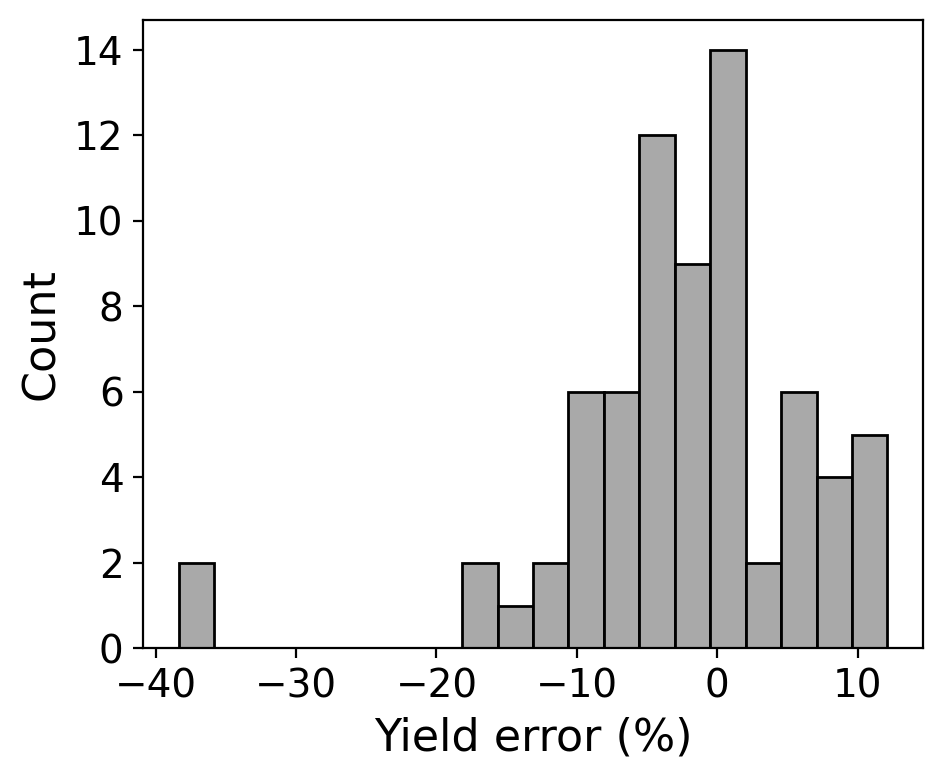

In [22]:
print("Plot of the mean errors across the training data")
hist_plot(train,"MAE","Yield error (%)",bins=20,bin_edges=None)

In [23]:
# get the predicted yields for compounds without experiment
pred_cand = final_model.predict(X_cand)
df_search = pd.DataFrame(pred_cand,index=candidates,columns=["yield"])

In [24]:
# add the experimental yields for the training set compounds (only the ones in the search space)
for smiles in space_smiles:
    if smiles not in candidates:
        df_search.loc[smiles,"yield"] = train.loc[train["SMILES"] == smiles, "yield"].values[0]
print("Size of the predicted search after augmentation with the experimental samples:",len(df_search))

Size of the predicted search after augmentation with the experimental samples: 2683


Yield distribution in the final dataset:


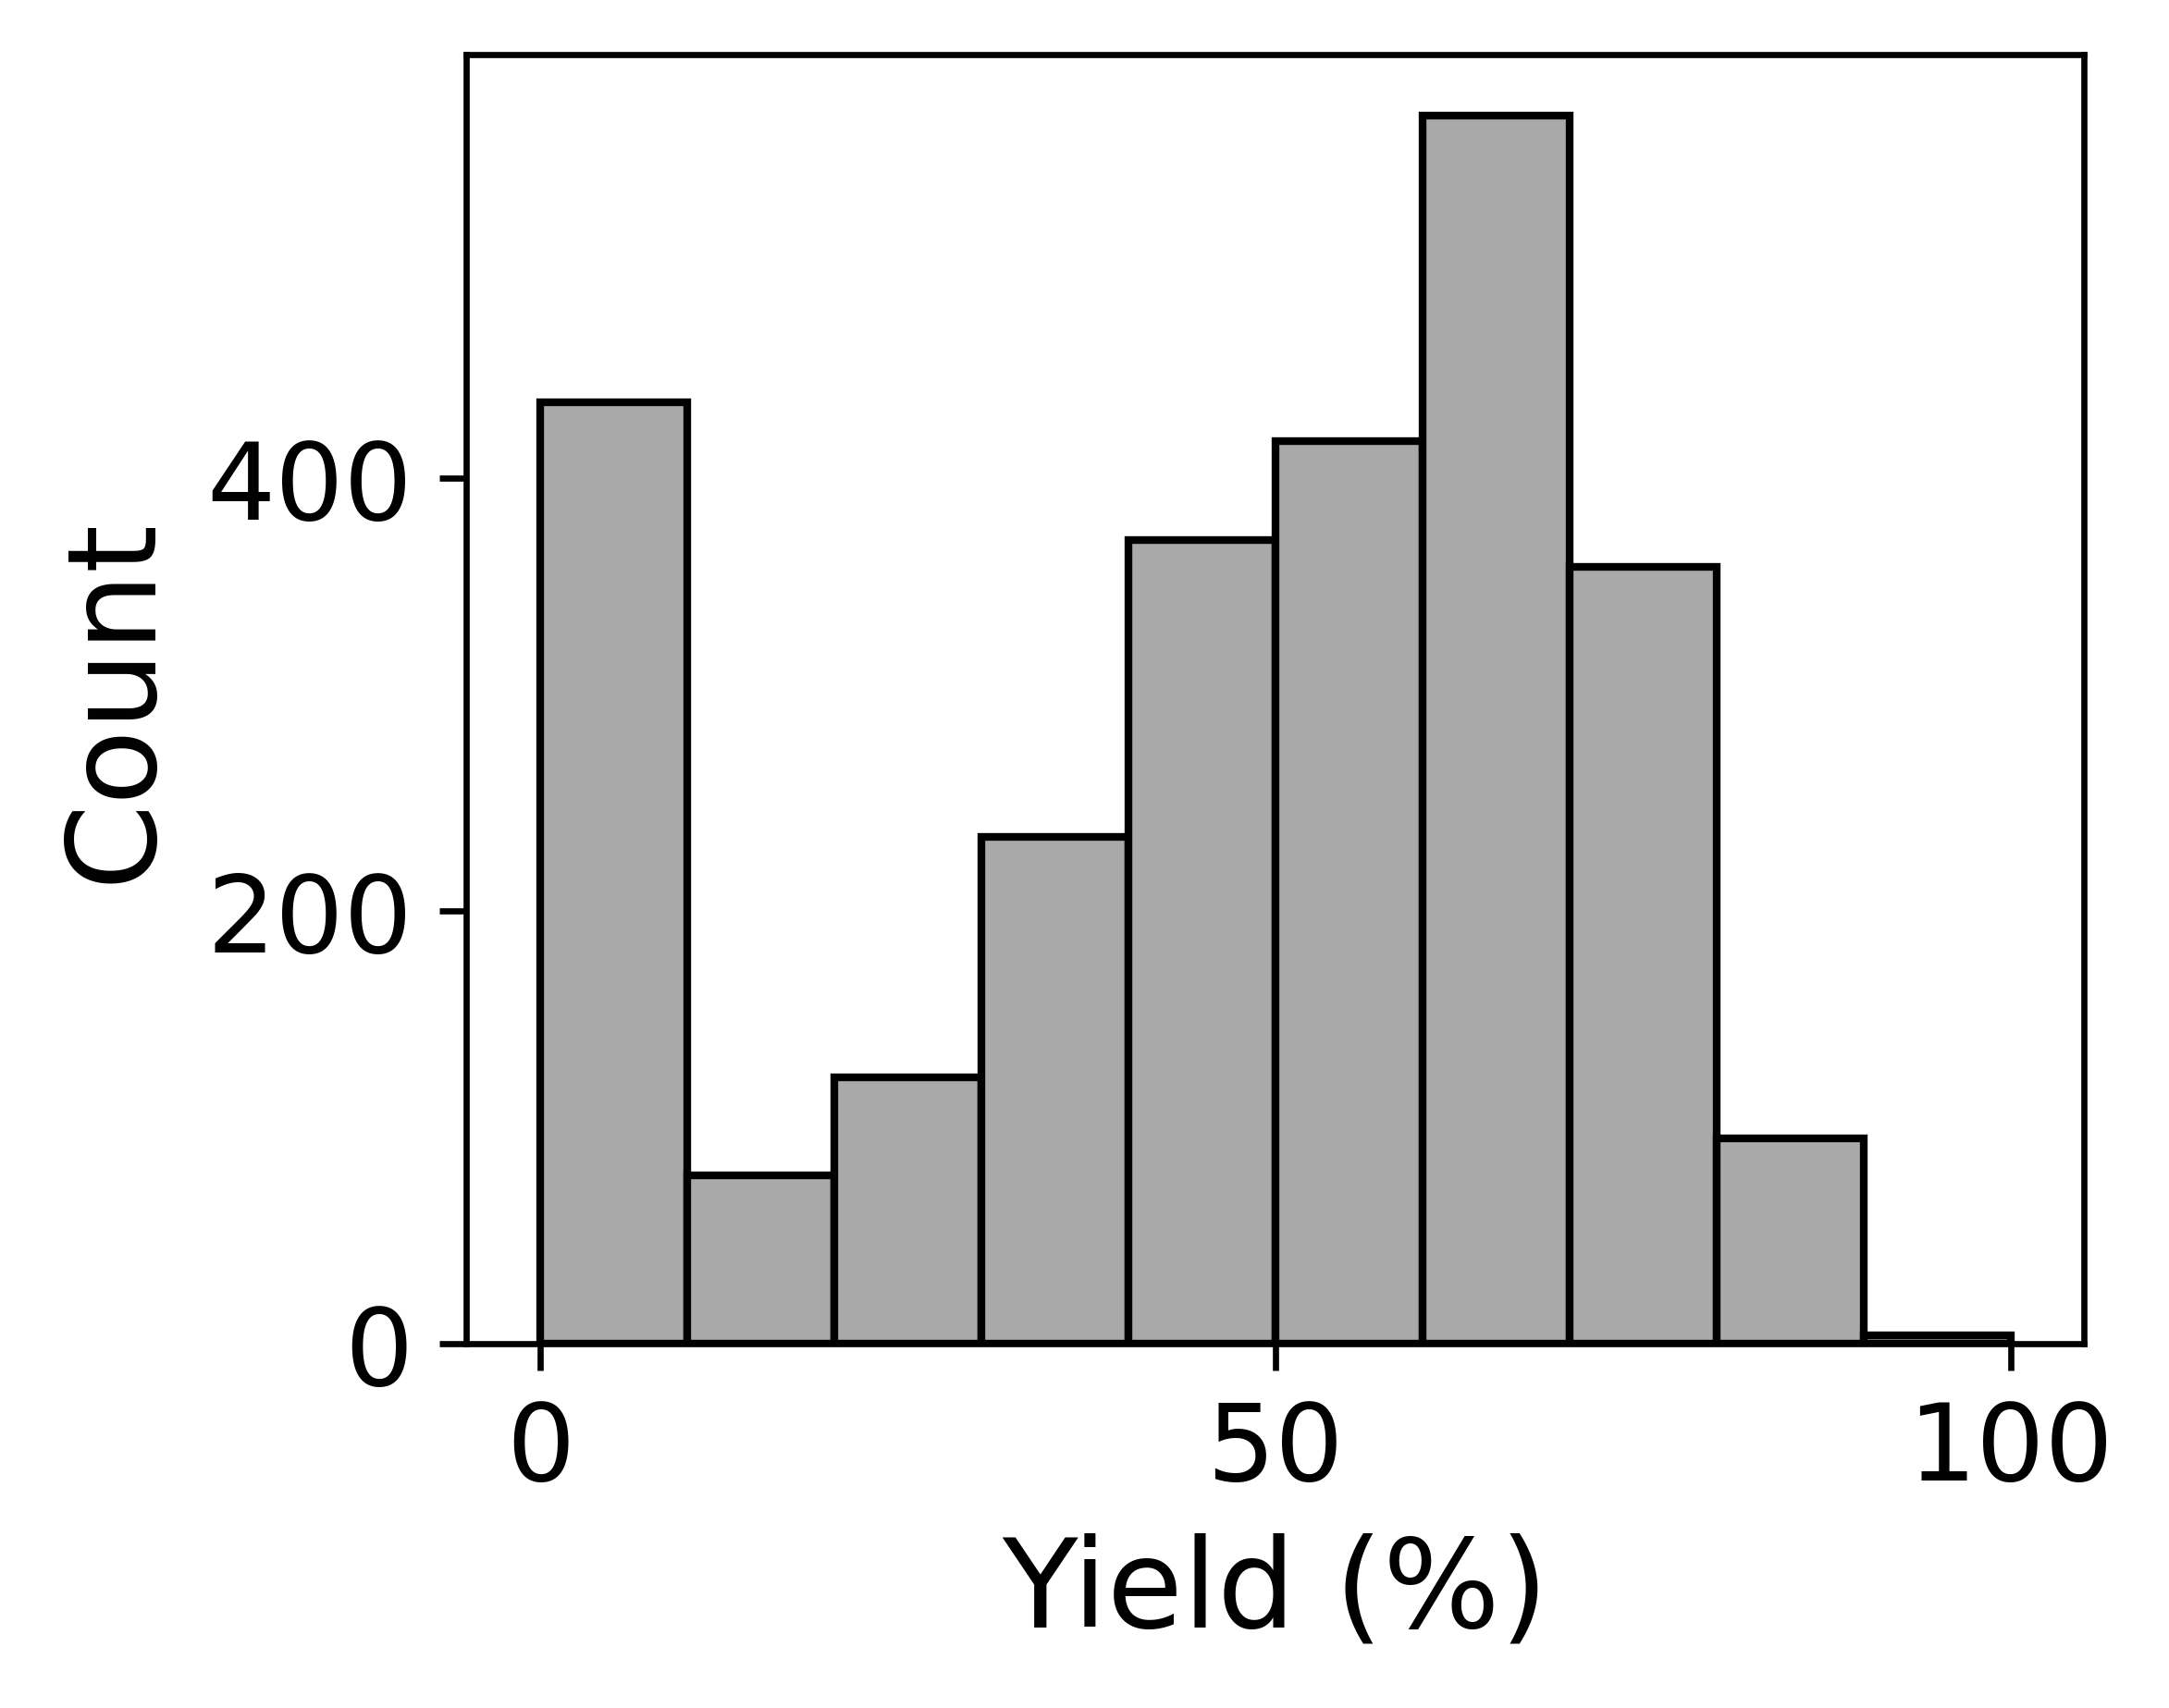

Mean yield: 46.5 %
Fraction with yield < 10%: 16 %
Fraction with yield ≥ 90%: 0.1 %


In [25]:
print("Yield distribution in the final dataset:")
hist_plot(df_search,"yield","Yield (%)",bins=10, dpi = 600, figsize=(4,3.18))
print("Mean yield:",round( df_search["yield"].mean(),1),"%")
print("Fraction with yield < 10%:", round(len(df_search[df_search["yield"] < 10])/ len(df_search)*100),"%")
print("Fraction with yield ≥ 90%:", round(len(df_search[df_search["yield"] >= 90])/ len(df_search)*100,1),"%")

In [26]:
# save the search space with the predicted yields
df_search.to_csv("arbr_pred_yields.csv",index=True,header=True)